In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data once
data = pd.read_csv("dataset/iris.csv")

# Split into features and target
X = data.drop("variety", axis=1)
y = data["variety"]

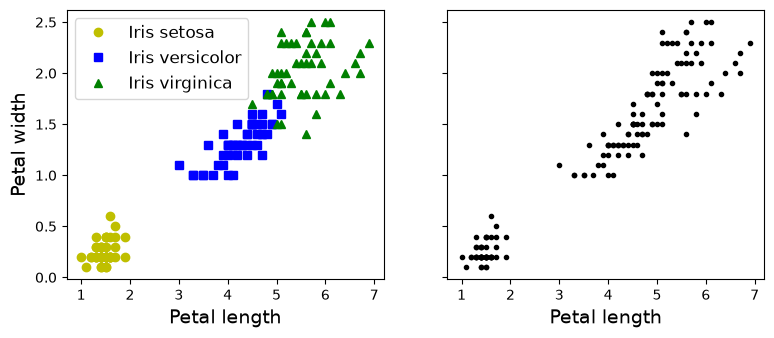

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 3.5))

# Сравниваем со строками (названиями видов)
plt.subplot(121)
plt.plot(X.iloc[y == "Setosa", 2], X.iloc[y == "Setosa", 3], "yo", label="Iris setosa")
plt.plot(X.iloc[y == "Versicolor", 2], X.iloc[y == "Versicolor", 3], "bs", label="Iris versicolor")
plt.plot(X.iloc[y == "Virginica", 2], X.iloc[y == "Virginica", 3], "g^", label="Iris virginica")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(fontsize=12)

plt.subplot(122)
plt.scatter(X.iloc[:, 2], X.iloc[:, 3], c="k", marker=".")
plt.xlabel("Petal length", fontsize=14)
plt.tick_params(labelleft=False)

plt.savefig("img/classification_vs_clustering_plot")
plt.show()

In [19]:
from sklearn.mixture import GaussianMixture

y_pred = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X)

In [20]:
from scipy import stats
import numpy as np

mapping = {}
for class_id in np.unique(y):
    mode = stats.mode(y_pred[y==class_id], keepdims=False)
    if np.isscalar(mode.mode):
        mapping[mode.mode] = class_id
    else:
        mapping[mode.mode[0]] = class_id

print(mapping)

{np.int64(1): 'Setosa', np.int64(2): 'Versicolor', np.int64(0): 'Virginica'}


In [21]:
y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred])

Mapping: {np.str_('Setosa'): 0, np.str_('Versicolor'): 1, np.str_('Virginica'): 2}


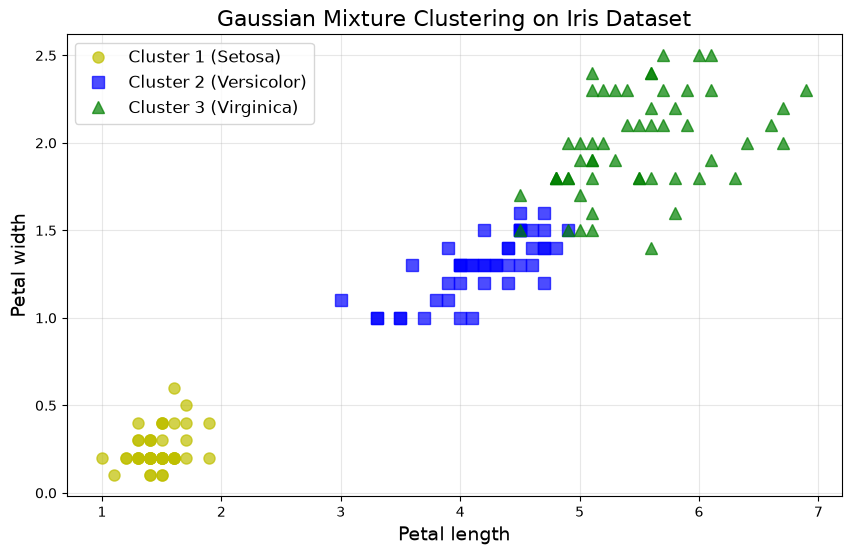

In [22]:
import numpy as np
import matplotlib.pyplot as plt

X_np = np.array(X)
y_pred_np = np.array(y_pred)

unique_classes = np.unique(y_pred_np)
class_to_num = {cls: i for i, cls in enumerate(unique_classes)}
y_pred_numeric = np.array([class_to_num[cls] for cls in y_pred_np])

print(f"Mapping: {class_to_num}")

plt.figure(figsize=(10, 6))

for i, (color, label) in enumerate(zip(['yo', 'bs', 'g^'], 
                                    [f'Cluster {i+1} ({cls})' for i, cls in enumerate(unique_classes)])):
    mask = y_pred_numeric == i
    if np.any(mask):
        plt.plot(X_np[mask, 2], X_np[mask, 3], color, label=label, alpha=0.7, markersize=8)

plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.grid(True, alpha=0.3)
plt.title("Gaussian Mixture Clustering on Iris Dataset", fontsize=16)
plt.show()

In [23]:
np.sum(y_pred==y)

np.int64(145)

In [24]:
np.sum(y_pred==y) / len(y_pred)

np.float64(0.9666666666666667)

In [25]:
from sklearn.datasets import make_blobs

blob_centers = np.array(
    [[ 0.2,  2.3],
    [-1.5 ,  2.3],
    [-2.8,  1.8],
    [-2.8,  2.8],
    [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

In [26]:
X, y = make_blobs(n_samples=2000, centers=blob_centers,
                cluster_std=blob_std, random_state=7)

In [27]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

In [ ]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.savefig("img/blobs_plot")
plt.show()